In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("AllCounts_V_4_4 (3).csv")

df.columns = [c.strip().lower() for c in df.columns] # standardize the data

# Normalize text columns
text_cols = ["site_name", "cammlr_region", "common_name", "count_type", "vantage", "reference"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.lower()

# we are Keeping only 3 species
keep_species = {"adelie penguin", "chinstrap penguin", "emperor penguin"}
df = df[df["common_name"].isin(keep_species)].copy()

# --- Create a clean date ---
# Some rows may have missing day; handle safely
df["day"] = pd.to_numeric(df["day"], errors="coerce")
df["month"] = pd.to_numeric(df["month"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# If day missing, set to 1 (can document this on website too)
df["day_filled"] = df["day"].fillna(1)

df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=df["day_filled"]),
    errors="coerce"
)

# Numeric cleaning
df["penguin_count"] = pd.to_numeric(df["penguin_count"], errors="coerce")
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="coerce")

# Remove invalid rows
df = df.dropna(subset=["date", "penguin_count", "latitude_epsg_4326", "longitude_epsg_4326"])
df = df[df["penguin_count"] >= 0].copy()


#  Remove duplicates
# Define a reasonable key (adjust if your dataset meaning differs)
dedupe_key = [
    "site_id", "site_name", "common_name", "date",
    "count_type", "vantage", "penguin_count"
]
df = df.drop_duplicates(subset=[k for k in dedupe_key if k in df.columns])

# features for analysis
df["log_count"] = np.log1p(df["penguin_count"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Save cleaned dataset
df.to_csv("penguins_3species_clean.csv", index=False)

print("Cleaned shape:", df.shape)
print(df["common_name"].value_counts())

Cleaned shape: (2471, 18)
common_name
adelie penguin       1326
chinstrap penguin    1054
emperor penguin        91
Name: count, dtype: int64


In [3]:
from google.colab import files #download the cleaned dataset
files.download("penguins_3species_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1) Load RAW
raw = pd.read_csv("AllCounts_V_4_4 (3).csv")
raw.columns = [c.strip().lower() for c in raw.columns]
raw["common_name"] = raw["common_name"].astype(str).str.strip().str.lower()

# 2) Clean into df (3 species)
keep = {"adelie penguin", "chinstrap penguin", "emperor penguin"}
df = raw[raw["common_name"].isin(keep)].copy()

for c in ["penguin_count","accuracy","year","month","day","latitude_epsg_4326","longitude_epsg_4326"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["day_filled"] = df["day"].fillna(1)
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=df["day_filled"]),
    errors="coerce"
)

df = df.dropna(subset=["penguin_count","date","latitude_epsg_4326","longitude_epsg_4326"])
df = df[df["penguin_count"] >= 0].copy()
df["log_count"] = np.log1p(df["penguin_count"])

# 3) BEFORE / AFTER snippets
before_snippet = raw.head(8)
after_snippet = df.head(8)

print("BEFORE (raw):")
display(before_snippet)

print("AFTER (cleaned):")
display(after_snippet)

# 4) Save cleaned dataset for download/snippets
df.to_csv("penguins_3species_clean.csv", index=False)
print("Saved cleaned file: penguins_3species_clean.csv")

BEFORE (raw):


,site_name,site_id,cammlr_region,longitude_epsg_4326,latitude_epsg_4326,common_name,day,month,year,season_starting,penguin_count,accuracy,count_type,vantage,reference
0,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,1993,1993,2008.0,1.0,nests,ground,"<p id=""coria2011laurie"" class=""reference"">Cori..."
1,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,1994,1994,1920.0,1.0,nests,NaN,"<p id=""woehler1997status"" class=""reference"">Wo..."
2,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,2004,2004,1880.0,1.0,nests,ground,"<p id=""coria2011laurie"" class=""reference"">Cori..."
3,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,25.0,2.0,2011,2010,3079.0,5.0,nests,vhr,"<p id=""lynch2014global"" class=""reference"">Lync..."
4,Acuna Island,ACUN,48.2,-44.637,-60.761,chinstrap penguin,28.0,12.0,1983,1983,4000.0,4.0,nests,ground,"<p id=""poncet1985survey"" class=""reference"">Pon..."
5,Acuna Island,ACUN,48.2,-44.637,-60.761,chinstrap penguin,NaN,NaN,2004,2004,7716.0,1.0,nests,ground,"<p id=""coria2011laurie"" class=""reference"">Cori..."
6,Acuna Island,ACUN,48.2,-44.637,-60.761,macaroni penguin,NaN,NaN,1993,1993,2.0,1.0,nests,ground,"<p id=""woehler1997status"" class=""reference"">Wo..."
7,Adams Island,ADAM,58.4.1,92.549,-66.546,adelie penguin,12.0,11.0,2009,2009,76.0,5.0,nests,vhr,"<p id=""lynch2014global"" class=""reference"">Lync..."


AFTER (cleaned):


,site_name,site_id,cammlr_region,longitude_epsg_4326,latitude_epsg_4326,common_name,day,month,year,season_starting,penguin_count,accuracy,count_type,vantage,reference,day_filled,date,log_count
3,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,25.0,2.0,2011,2010,3079.0,5.0,nests,vhr,"<p id=""lynch2014global"" class=""reference"">Lync...",25.0,2011-02-25,8.032685
4,Acuna Island,ACUN,48.2,-44.637,-60.761,chinstrap penguin,28.0,12.0,1983,1983,4000.0,4.0,nests,ground,"<p id=""poncet1985survey"" class=""reference"">Pon...",28.0,1983-12-28,8.294300
7,Adams Island,ADAM,58.4.1,92.549,-66.546,adelie penguin,12.0,11.0,2009,2009,76.0,5.0,nests,vhr,"<p id=""lynch2014global"" class=""reference"">Lync...",12.0,2009-11-12,4.343805
8,Adams Island,ADAM,58.4.1,92.549,-66.546,adelie penguin,21.0,1.0,2011,2010,425.0,1.0,adults,aerial photo,"<p id=""southwell2013population"" class=""referen...",21.0,2011-01-21,6.054439
10,Cape Adare,ADAR,88.1,170.200,-71.306,adelie penguin,NaN,12.0,1983,1983,241272.0,2.0,nests,aerial,"<p id=""manaakiwhenua2021aerial"" class=""referen...",1.0,1983-12-01,12.393684
11,Cape Adare,ADAR,88.1,170.200,-71.306,adelie penguin,NaN,12.0,1986,1986,238830.0,2.0,nests,aerial,"<p id=""manaakiwhenua2021aerial"" class=""referen...",1.0,1986-12-01,12.383511
12,Cape Adare,ADAR,88.1,170.200,-71.306,adelie penguin,NaN,12.0,1988,1988,272338.0,2.0,nests,aerial,"<p id=""manaakiwhenua2021aerial"" class=""referen...",1.0,1988-12-01,12.514803
13,Cape Adare,ADAR,88.1,170.200,-71.306,adelie penguin,NaN,12.0,1990,1990,169200.0,2.0,nests,aerial,"<p id=""manaakiwhenua2021aerial"" class=""referen...",1.0,1990-12-01,12.038843


Saved cleaned file: penguins_3species_clean.csv


##Summary table


In [5]:
import pandas as pd

df = pd.read_csv("penguins_3species_clean.csv")

# Summary stats by species
summary = df.groupby("common_name")["penguin_count"].agg(
    n="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).round(2)

print(summary)

# Missingness overview
missing = df.isna().mean().sort_values(ascending=False).round(3)
print(missing.head(15))

                      n      mean  median       std  min       max
common_name                                                       
adelie penguin     1330  17693.87  2404.5  46267.89  0.0  504332.0
chinstrap penguin  1073   4640.30   566.0  17620.45  0.0  300000.0
emperor penguin      91   4145.96  1745.0   5538.43  0.0   25298.0
day                    0.225
vantage                0.046
site_id                0.000
site_name              0.000
latitude_epsg_4326     0.000
cammlr_region          0.000
common_name            0.000
month                  0.000
year                   0.000
longitude_epsg_4326    0.000
season_starting        0.000
penguin_count          0.000
accuracy               0.000
count_type             0.000
reference              0.000
dtype: float64


##Visualisation


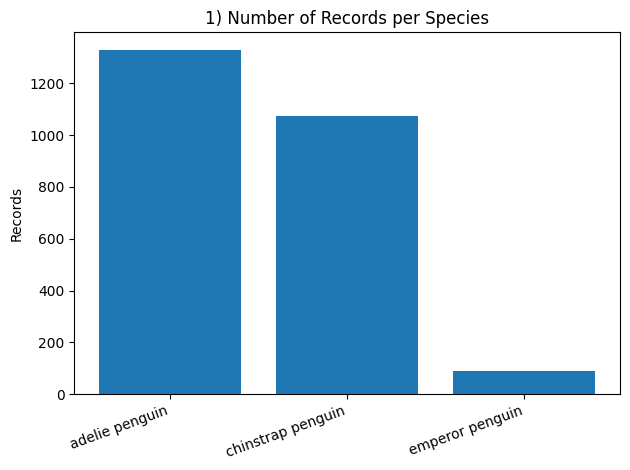

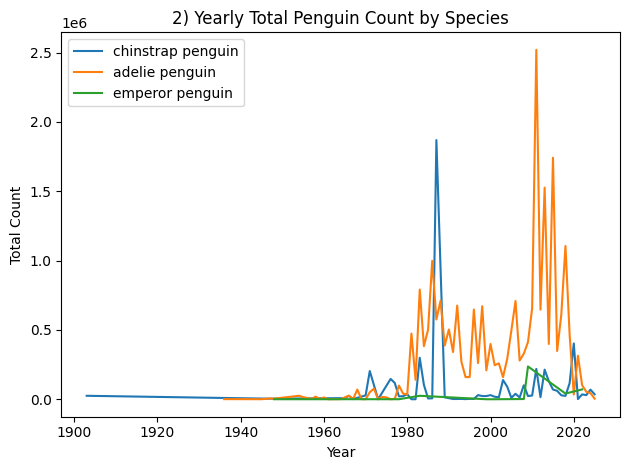

/tmp/ipykernel_485/1433076977.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=species_order)


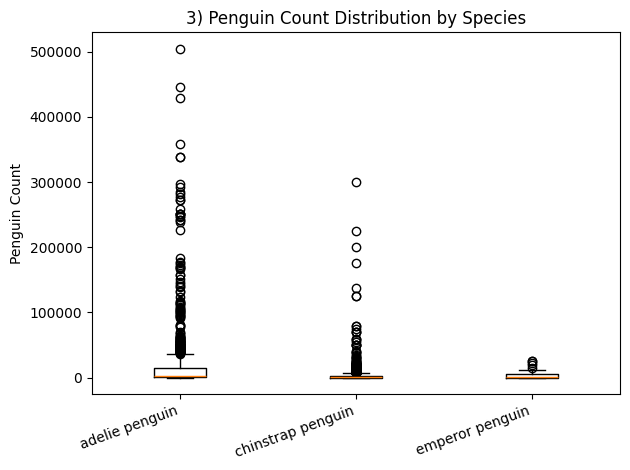

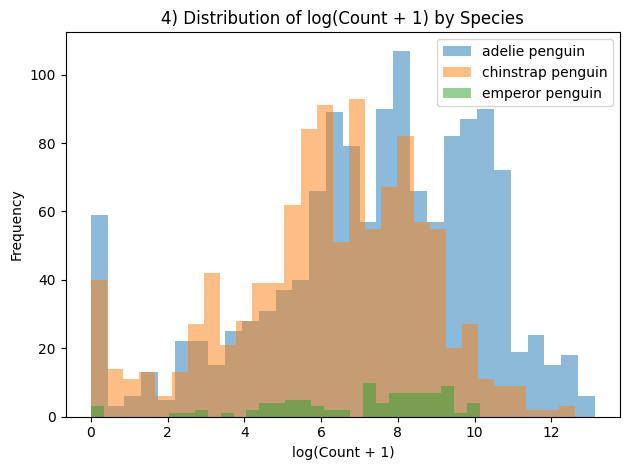

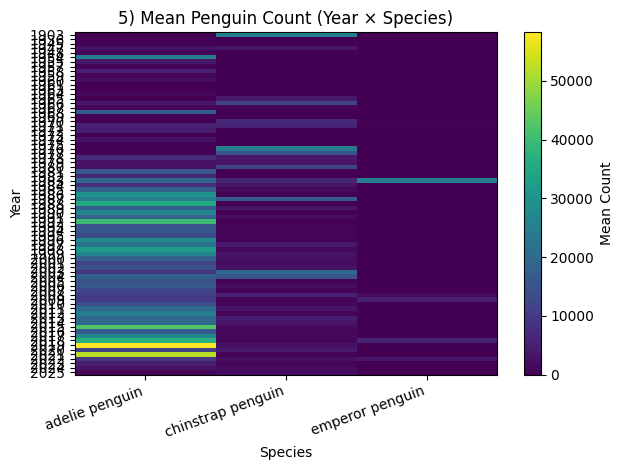

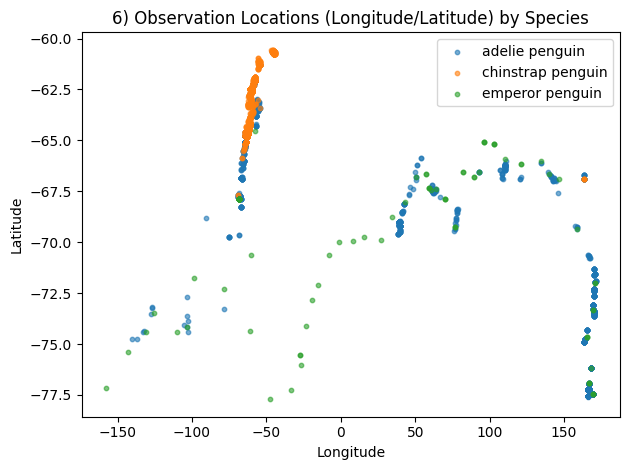

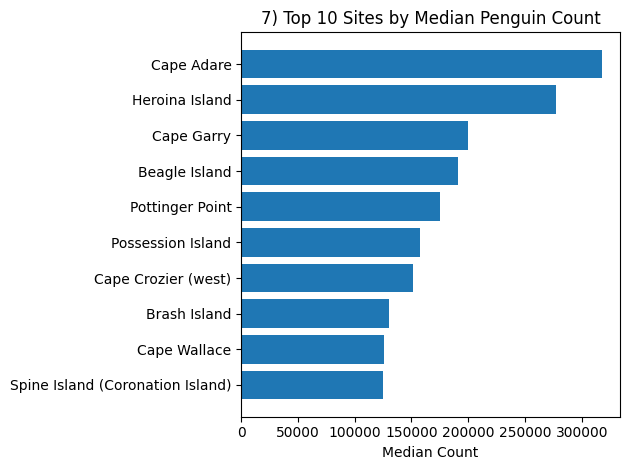

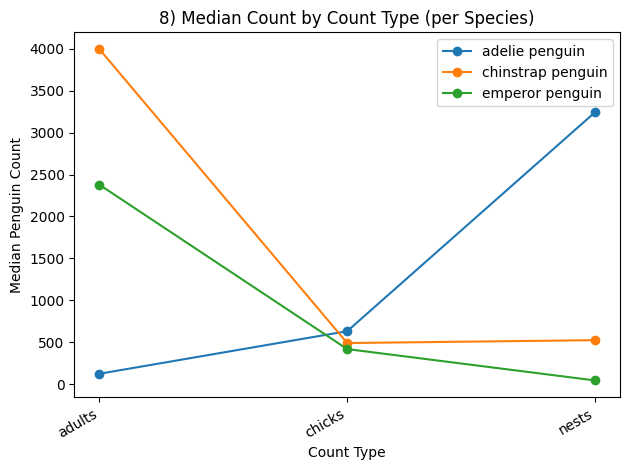

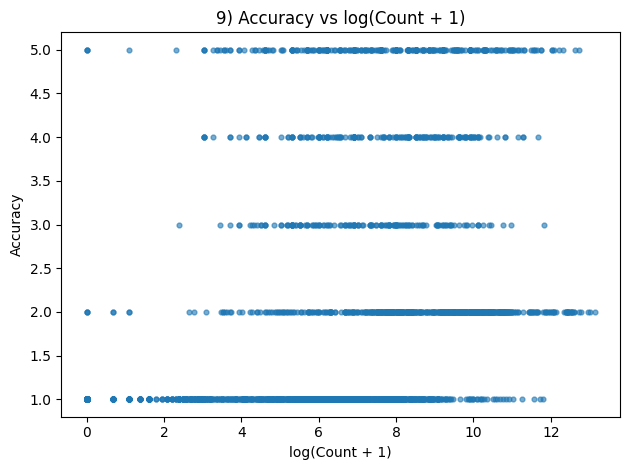

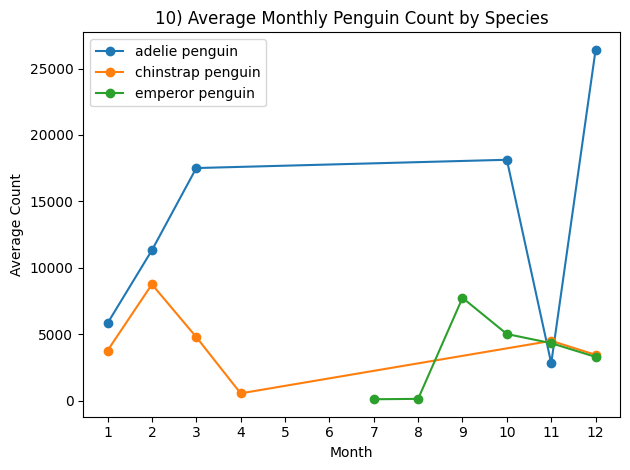

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# LOAD + CLEAN (3 species)

df = pd.read_csv("AllCounts_V_4_4 (3).csv")

df.columns = [c.strip().lower() for c in df.columns]
df["common_name"] = df["common_name"].astype(str).str.strip().str.lower()

keep = {"adelie penguin", "chinstrap penguin", "emperor penguin"}
df = df[df["common_name"].isin(keep)].copy()

# numeric conversions
for c in ["penguin_count", "accuracy", "year", "month", "day",
          "latitude_epsg_4326", "longitude_epsg_4326"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# date creation (fill missing day with 1)
df["day_filled"] = df["day"].fillna(1)
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=df["day_filled"]),
    errors="coerce"
)

# drop invalids
df = df.dropna(subset=["penguin_count", "date", "latitude_epsg_4326", "longitude_epsg_4326"])
df = df[df["penguin_count"] >= 0].copy()
df["log_count"] = np.log1p(df["penguin_count"])

species_order = ["adelie penguin", "chinstrap penguin", "emperor penguin"]

# 10 VISUALIZATIONS


# 1) Bar: number of records per species
counts = df["common_name"].value_counts()
plt.figure()
plt.bar(counts.index, counts.values)
plt.xticks(rotation=20, ha="right")
plt.title("1) Number of Records per Species")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

# 2) Line: yearly total count trend per species
trend = df.groupby(["year", "common_name"])["penguin_count"].sum().reset_index()
plt.figure()
for sp in trend["common_name"].unique():
    d = trend[trend["common_name"] == sp].sort_values("year")
    plt.plot(d["year"], d["penguin_count"], label=sp)
plt.title("2) Yearly Total Penguin Count by Species")
plt.xlabel("Year")
plt.ylabel("Total Count")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Boxplot: distribution of counts by species
data = [df[df["common_name"] == sp]["penguin_count"].values for sp in species_order]
plt.figure()
plt.boxplot(data, labels=species_order)
plt.xticks(rotation=20, ha="right")
plt.title("3) Penguin Count Distribution by Species")
plt.ylabel("Penguin Count")
plt.tight_layout()
plt.show()

# 4) Histogram overlay: log(count+1) by species
plt.figure()
for sp in species_order:
    x = df[df["common_name"] == sp]["log_count"].dropna()
    plt.hist(x, bins=30, alpha=0.5, label=sp)
plt.title("4) Distribution of log(Count + 1) by Species")
plt.xlabel("log(Count + 1)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Heatmap: mean count by year × species
pivot = df.pivot_table(index="year", columns="common_name", values="penguin_count", aggfunc="mean").sort_index()
pivot = pivot.reindex(columns=[c for c in species_order if c in pivot.columns])
plt.figure()
plt.imshow(pivot.fillna(0).values, aspect="auto")
plt.title("5) Mean Penguin Count (Year × Species)")
plt.xlabel("Species")
plt.ylabel("Year")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=20, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Mean Count")
plt.tight_layout()
plt.show()

# 6) Geographic scatter: lon/lat by species
plt.figure()
for sp in species_order:
    d = df[df["common_name"] == sp]
    plt.scatter(d["longitude_epsg_4326"], d["latitude_epsg_4326"], s=10, alpha=0.6, label=sp)
plt.title("6) Observation Locations (Longitude/Latitude) by Species")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

# 7) Barh: top 10 sites by median count
# (drop missing site_name safely)
if "site_name" in df.columns:
    site_med = df.dropna(subset=["site_name"]).groupby("site_name")["penguin_count"].median().sort_values(ascending=False).head(10)
    plt.figure()
    plt.barh(site_med.index[::-1], site_med.values[::-1])
    plt.title("7) Top 10 Sites by Median Penguin Count")
    plt.xlabel("Median Count")
    plt.tight_layout()
    plt.show()

# 8) Line (categorical x): median count by count_type per species
if "count_type" in df.columns:
    d2 = df.dropna(subset=["count_type"]).copy()
    d2["count_type"] = d2["count_type"].astype(str).str.strip().str.lower()
    g = d2.groupby(["count_type", "common_name"])["penguin_count"].median().reset_index()

    plt.figure()
    for sp in species_order:
        ds = g[g["common_name"] == sp].sort_values("count_type")
        if len(ds) > 0:
            plt.plot(ds["count_type"], ds["penguin_count"], marker="o", label=sp)
    plt.title("8) Median Count by Count Type (per Species)")
    plt.xlabel("Count Type")
    plt.ylabel("Median Penguin Count")
    plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 9) Scatter: accuracy vs log(count+1)
if "accuracy" in df.columns:
    d3 = df.dropna(subset=["accuracy"])
    plt.figure()
    plt.scatter(d3["log_count"], d3["accuracy"], s=12, alpha=0.6)
    plt.title("9) Accuracy vs log(Count + 1)")
    plt.xlabel("log(Count + 1)")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.show()

# 10) Monthly pattern: average monthly count by species
monthly = df.groupby(["month", "common_name"])["penguin_count"].mean().reset_index()
plt.figure()
for sp in species_order:
    d = monthly[monthly["common_name"] == sp].sort_values("month")
    if len(d) > 0:
        plt.plot(d["month"], d["penguin_count"], marker="o", label=sp)
plt.title("10) Average Monthly Penguin Count by Species")
plt.xlabel("Month")
plt.ylabel("Average Count")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

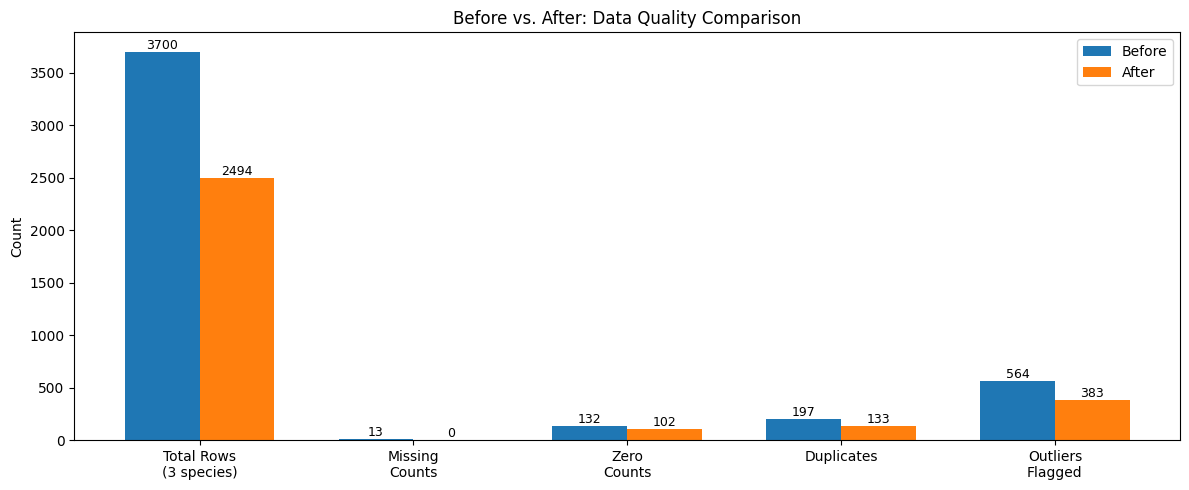

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# LOAD (BEFORE)

raw = pd.read_csv("AllCounts_V_4_4 (3).csv")
raw.columns = [c.strip().lower() for c in raw.columns]
raw["common_name"] = raw["common_name"].astype(str).str.strip().str.lower()

keep = {"adelie penguin", "chinstrap penguin", "emperor penguin"}
before = raw[raw["common_name"].isin(keep)].copy()

# Make penguin_count numeric for quality checks
before["penguin_count"] = pd.to_numeric(before["penguin_count"], errors="coerce")


# CLEAN (AFTER)

after = before.copy()

# numeric conversions
for c in ["accuracy","year","month","day","latitude_epsg_4326","longitude_epsg_4326"]:
    if c in after.columns:
        after[c] = pd.to_numeric(after[c], errors="coerce")

# date creation
after["day_filled"] = after["day"].fillna(1)
after["date"] = pd.to_datetime(dict(year=after["year"], month=after["month"], day=after["day_filled"]), errors="coerce")

# apply cleaning rules
after = after.dropna(subset=["penguin_count","date","latitude_epsg_4326","longitude_epsg_4326"])
after = after[after["penguin_count"] >= 0].copy()


# QUALITY METRICS

# Duplicates: use a reasonable key (adjust if needed)
dup_key = ["site_name","common_name","date","count_type","vantage","penguin_count"]
dup_key = [k for k in dup_key if k in before.columns]

before_total = len(before)
after_total  = len(after)

before_missing = before["penguin_count"].isna().sum()
after_missing  = after["penguin_count"].isna().sum()

before_zero = (before["penguin_count"] == 0).sum()
after_zero  = (after["penguin_count"] == 0).sum()

before_dups = before.duplicated(subset=dup_key).sum() if len(dup_key) > 0 else 0
after_dups  = after.duplicated(subset=dup_key).sum() if len(dup_key) > 0 else 0

# Outliers flagged using IQR rule (on non-missing counts)
def iqr_outliers_count(series):
    s = series.dropna()
    if len(s) < 4:
        return 0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return ((s < low) | (s > high)).sum()

before_outliers = iqr_outliers_count(before["penguin_count"])
after_outliers  = iqr_outliers_count(after["penguin_count"])

labels = [
    "Total Rows\n(3 species)",
    "Missing\nCounts",
    "Zero\nCounts",
    "Duplicates",
    "Outliers\nFlagged"
]

before_vals = [before_total, before_missing, before_zero, before_dups, before_outliers]
after_vals  = [after_total,  after_missing,  after_zero,  after_dups,  after_outliers]


# PLOT

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(12,5))
b1 = plt.bar(x - w/2, before_vals, width=w, label="Before")
b2 = plt.bar(x + w/2, after_vals,  width=w, label="After")

plt.title("Before vs. After: Data Quality Comparison")
plt.ylabel("Count")
plt.xticks(x, labels)
plt.legend()

# add value labels on bars
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


